# Introduction to Recommender Systems

<p align="center">
    <img width="721" alt="cover-image" src="https://user-images.githubusercontent.com/49638680/204351915-373011d3-75ac-4e21-a6df-99cd1c552f2c.png">
</p>

---

# TP — A book recommender on GoodBooks-10k (proposed solution)

This notebook is the worked solution of the exercise described in
[`BookRecommender_exercise.ipynb`](./BookRecommender_exercise.ipynb): build, evaluate and
discuss a recommender system on the [GoodBooks-10k](https://github.com/zygmuntz/goodbooks-10k)
dataset (10 000 books, ~6 million ratings from ~53 000 readers).

**What we do, in order**

| Part | Question | Outcome |
|---|---|---|
| 1 | What does the data look like? | Distributions, long tail, sparsity, missing values |
| 2 | Which features can we build? | Id encoding, popularity, TF-IDF content (title + authors + tags) |
| 3 | How do we evaluate honestly? | Per-user 80/20 split, RMSE/MAE **and** Precision/Recall/NDCG@10 |
| 4 | Can we predict a rating? | Biased matrix factorisation, RMSE 0.85 vs 0.99 for the global mean |
| 5 | Can we build a good top-10 list? | The RMSE winner is a **poor** ranker; item-kNN + content hybrid wins |
| 6 | What drives performance? | Ablations on dataset size, content features, neighbourhood size, blend weight |
| 7 | And for a brand new reader? | Cold-start simulation: content-based saves the day |
| 8 | Show me recommendations | `top_n_recommendations()` for real users, plus "similar books" |

Every reusable piece of code lives in [`src/utils/book_recommender.py`](../utils/book_recommender.py)
and is unit-tested in [`src/tests/test_book_recommender.py`](../tests/test_book_recommender.py);
the notebook keeps only the analysis and the discussion.

## 0. Setup

The dataset is **not** committed to the repository (the `data/` folder is git-ignored).
The cell below downloads it once — about 100 MB unzipped.

In [1]:
%%bash
bash ../../scripts/download_goodbooks.sh

Data already downloaded in /home/user/Recommender-Systems-Course/data/goodbooks-10k


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The shared helpers live in `src/utils`, one level above this notebook.
src_root = Path("..").resolve()
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from utils import book_recommender as br

DATA_DIR = Path("../../data/goodbooks-10k")
SEED = 42
K = 10  # length of the recommendation lists we evaluate

plt.rcParams["figure.figsize"] = (14, 6)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 60)
%matplotlib inline

## 1. Data analysis

> *"Justify all the choices you make as results of some data analysis."*

So we start by looking at the data, and every modelling decision taken later in the notebook
points back to one of the observations made here.

In [3]:
data = br.load_goodbooks(DATA_DIR)
books, ratings = data["books"], data["ratings"]
book_tags, tags = data["book_tags"], data["tags"]

print(f"books     : {books.shape[0]:>9,} rows x {books.shape[1]} columns")
print(f"ratings   : {ratings.shape[0]:>9,} rows x {ratings.shape[1]} columns")
print(f"book_tags : {book_tags.shape[0]:>9,} rows")
print(f"tags      : {tags.shape[0]:>9,} rows")
books.head(3)

books     :    10,000 rows x 23 columns
ratings   : 5,976,479 rows x 3 columns
book_tags :   999,912 rows
tags      :    34,252 rows


,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m/2767052.jpg,https://images.gr-assets.com/books/1447303603s/2767052.jpg
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m/3.jpg,https://images.gr-assets.com/books/1474154022s/3.jpg
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m/41865.jpg,https://images.gr-assets.com/books/1361039443s/41865.jpg


In [4]:
n_users = ratings.user_id.nunique()
n_books = ratings.book_id.nunique()
density = len(ratings) / (n_users * n_books)

print(f"{len(ratings):,} ratings from {n_users:,} readers on {n_books:,} books")
print(f"density of the rating matrix: {100 * density:.2f}%  "
      f"({100 * (1 - density):.2f}% of the matrix is missing)")
print(f"duplicated (user, book) pairs: {ratings.duplicated(['user_id', 'book_id']).sum()}")
print(f"ratings per reader : min {ratings.groupby('user_id').size().min()}, "
      f"median {ratings.groupby('user_id').size().median():.0f}, "
      f"max {ratings.groupby('user_id').size().max()}")
print(f"ratings per book   : min {ratings.groupby('book_id').size().min()}, "
      f"median {ratings.groupby('book_id').size().median():.0f}, "
      f"max {ratings.groupby('book_id').size().max()}")

5,976,479 ratings from 53,424 readers on 10,000 books
density of the rating matrix: 1.12%  (98.88% of the matrix is missing)


duplicated (user, book) pairs: 0


ratings per reader : min 19, median 111, max 200


ratings per book   : min 8, median 248, max 22806


### 1.1 Missing values

Only the *metadata* table has holes; the ratings themselves are complete (no NaN, no duplicate
pair, no rating outside 1-5). That matters: the collaborative models below need nothing else
than `(user_id, book_id, rating)`, so **no rating has to be dropped or imputed**.

In [5]:
missing = (
    books.isna().sum().loc[lambda s: s > 0].to_frame("missing")
    .assign(percent=lambda df: 100 * df.missing / len(books))
    .sort_values("missing", ascending=False)
)
display(missing)

print("ratings table — missing values:", ratings.isna().sum().sum())
print("ratings outside [1, 5]:", ((ratings.rating < 1) | (ratings.rating > 5)).sum())

,missing,percent
language_code,1084,10.84
isbn,700,7.00
isbn13,585,5.85
original_title,585,5.85
original_publication_year,21,0.21


ratings table — missing values: 0
ratings outside [1, 5]: 0


**Decisions taken (and why):**

| Column | Missing | Decision |
|---|---|---|
| `isbn`, `isbn13` | ~6-7 % | **Dropped**: identifiers, useless as features. |
| `original_title` | 5.9 % | **Kept**, filled with `""` — `title` is always present, so the text document never ends up empty. |
| `language_code` | 10.8 % | **Not used**: imputing a language would invent information, and the labelled editions are ~97 % English anyway. |
| `original_publication_year` | 0.2 % | **Kept** for the analysis only, not used as a model feature. |

No row of `books.csv` is deleted: a book with a missing ISBN is still a perfectly good
item to recommend.

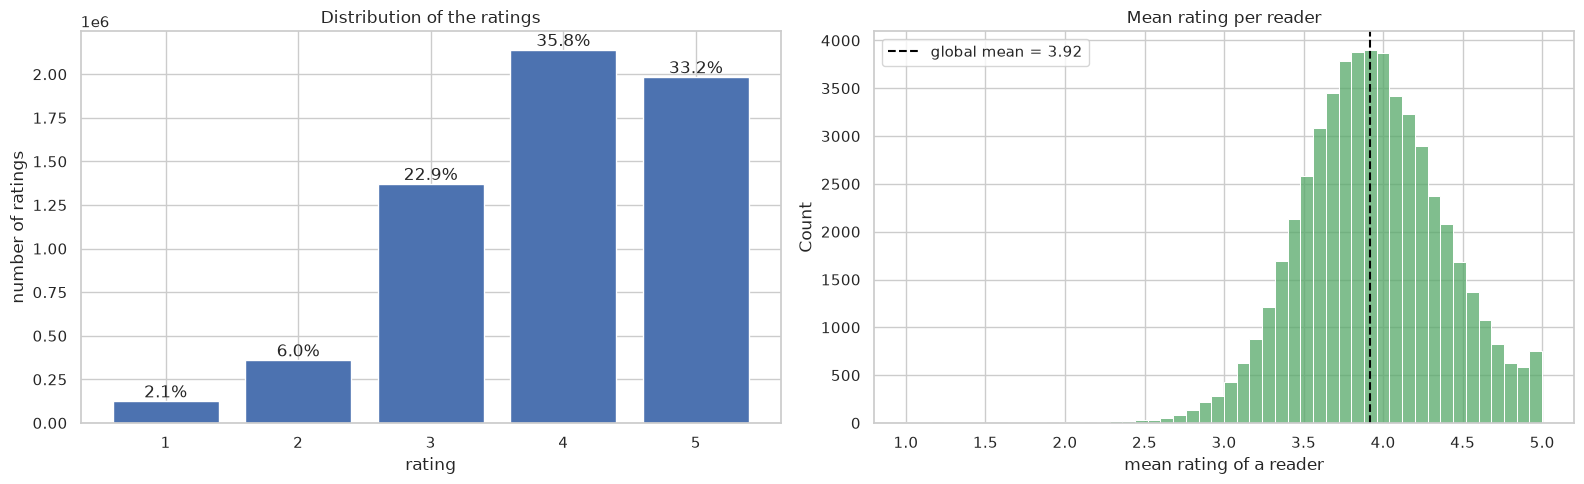

global mean rating : 3.920
share of ratings >= 4 : 69.0%
std of the per-reader mean rating : 0.450


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

counts = ratings.rating.value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color=sns.color_palette()[0])
axes[0].set(title="Distribution of the ratings", xlabel="rating", ylabel="number of ratings")
for rating, count in counts.items():
    axes[0].text(rating, count, f"{100 * count / len(ratings):.1f}%", ha="center", va="bottom")

user_means = ratings.groupby("user_id").rating.mean()
sns.histplot(user_means, bins=50, ax=axes[1], color=sns.color_palette()[2])
axes[1].axvline(ratings.rating.mean(), color="black", ls="--",
                label=f"global mean = {ratings.rating.mean():.2f}")
axes[1].set(title="Mean rating per reader", xlabel="mean rating of a reader")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"global mean rating : {ratings.rating.mean():.3f}")
print(f"share of ratings >= 4 : {100 * (ratings.rating >= 4).mean():.1f}%")
print(f"std of the per-reader mean rating : {user_means.std():.3f}")

**Observation 1 — the ratings are strongly skewed towards the positive.**
69 % of the ratings are 4 or 5 and only 2 % are 1. Two consequences we act upon later:

* a constant predictor already reaches an RMSE below 1, so the *global mean* is the
  baseline any model has to beat (Part 4);
* "the reader liked the book" is well captured by `rating >= 4`, the relevance threshold we
  use for the ranking metrics (Part 5).

**Observation 2 — readers rate on different scales.** The per-reader mean spans the whole
scale (std 0.45), which is exactly what the *user bias* term `b_u` of the matrix
factorisation model absorbs.

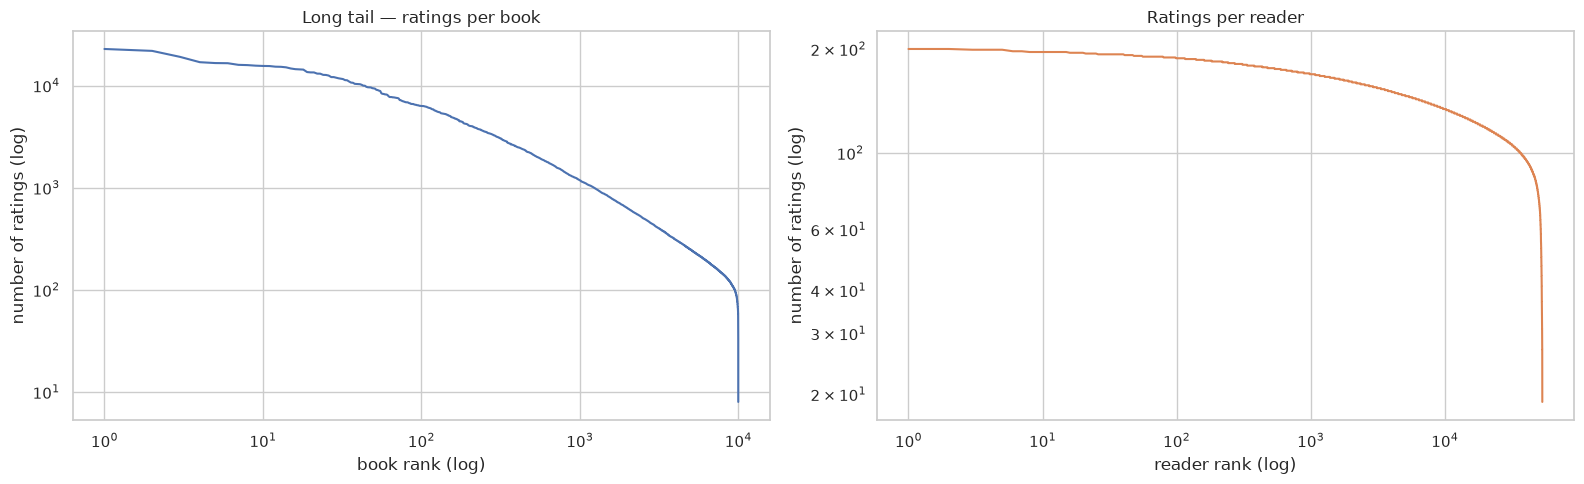

the top 1% of books (100 titles) collect 17.1% of all ratings
the bottom 50% of books collect 13.2% of all ratings


,count,mean,std,min,25%,50%,75%,max
ratings per book,10000.0,597.6479,1267.289788,8.0,155.0,248.0,503.0,22806.0


In [7]:
ratings_per_book = ratings.groupby("book_id").size().sort_values(ascending=False)
ratings_per_user = ratings.groupby("user_id").size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(np.arange(1, len(ratings_per_book) + 1), ratings_per_book.values)
axes[0].set(xscale="log", yscale="log", title="Long tail — ratings per book",
            xlabel="book rank (log)", ylabel="number of ratings (log)")
axes[1].plot(np.arange(1, len(ratings_per_user) + 1), ratings_per_user.values,
             color=sns.color_palette()[1])
axes[1].set(xscale="log", yscale="log", title="Ratings per reader",
            xlabel="reader rank (log)", ylabel="number of ratings (log)")
plt.tight_layout()
plt.show()

top_1_percent = int(0.01 * len(ratings_per_book))
print(f"the top 1% of books ({top_1_percent} titles) collect "
      f"{100 * ratings_per_book.head(top_1_percent).sum() / len(ratings):.1f}% of all ratings")
print(f"the bottom 50% of books collect "
      f"{100 * ratings_per_book.tail(len(ratings_per_book) // 2).sum() / len(ratings):.1f}% of all ratings")
display(ratings_per_book.describe().to_frame("ratings per book").T)

**Observation 3 — the usual long tail, but a mild one.** The top 1 % of the books gather 17 %
of the ratings, the bottom half only 13 %, and *every* book has at least 8 ratings: GoodBooks-10k is already a filtered
catalogue (the 10 000 most popular books of Goodreads). So, contrary to the MovieLens notebook
of Session 01, **we do not need to prune the data** — there is no item that would be impossible
to learn anything about. We keep the 6 million ratings.

Note the contrast with the readers' side: the curve is much flatter (every reader has between
19 and 200 ratings), because the dataset was built by sampling active users.

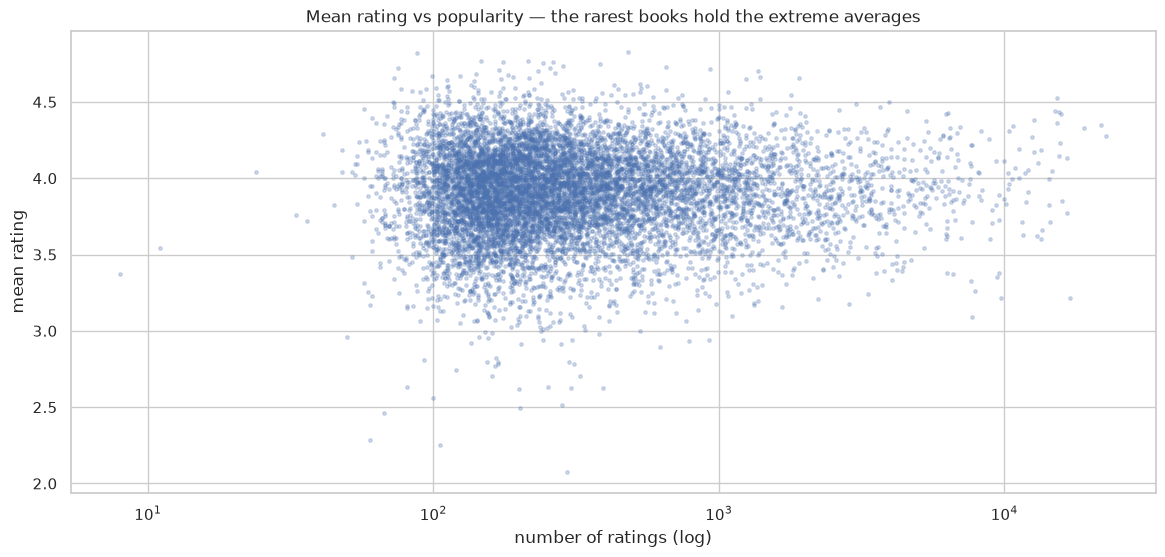

Top 5 books by raw mean rating (no damping):


,title,count,mean
book_id,,,
3628,The Complete Calvin and Hobbes,482,4.829876
7947,ESV Study Bible,88,4.818182
9566,Attack of the Deranged Mutant Killer Monster Snow Goons,147,4.768707
6920,The Indispensable Calvin and Hobbes,214,4.766355
8978,The Revenge of the Baby-Sat,176,4.761364


Top 5 books by number of ratings:


,title,count,mean
book_id,,,
1,"The Hunger Games (The Hunger Games, #1)",22806,4.279707
2,"Harry Potter and the Sorcerer's Stone (Harry Potter, #1)",21850,4.351350
4,To Kill a Mockingbird,19088,4.329369
3,"Twilight (Twilight, #1)",16931,3.214341
5,The Great Gatsby,16604,3.772224


In [8]:
popularity = (
    ratings.groupby("book_id").rating.agg(["count", "mean"])
    .join(books.set_index("book_id")[["title", "authors"]])
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(popularity["count"], popularity["mean"], s=6, alpha=0.25)
ax.set(xscale="log", xlabel="number of ratings (log)", ylabel="mean rating",
       title="Mean rating vs popularity — the rarest books hold the extreme averages")
plt.show()

print("Top 5 books by raw mean rating (no damping):")
display(popularity.sort_values("mean", ascending=False).head(5)[["title", "count", "mean"]])
print("Top 5 books by number of ratings:")
display(popularity.sort_values("count", ascending=False).head(5)[["title", "count", "mean"]])

**Observation 4 — a raw mean rating is not a ranking criterion.** The best-rated books are
rated by a few hundred readers, while the blockbusters sit around 4.2-4.3. This is why the
popularity baseline of Part 4 uses a **damped (Bayesian) mean**

$$\hat r_i = \frac{n_i \bar r_i + m \mu}{n_i + m}, \qquad m = 25,$$

which pulls poorly-supported books back towards the global mean $\mu$.

---

## 2. Feature engineering

### 2.1 Encoding the ids

`user_id` and `book_id` are identifiers, not numbers: nothing says that book 42 is
"between" book 41 and book 43. Every model below works on **contiguous integer indices**
(`0 … n-1`) that address the rows and columns of the rating matrix. `br.IdIndex` stores both
directions of the mapping, so we can always come back to a readable title.

### 2.2 The train/test split comes first

A subtlety worth stating before we build anything: the split must be done **before** any
statistic is computed, otherwise the popularity feature would be derived from ratings we
then pretend not to know.

We hold out **20 % of each reader's history**, not 20 % of the rows: a plain random split
would leave some readers entirely in the test set, and no personalised model can say anything
about a reader it never saw. Books or readers that would end up only in the test set are
dropped from it.

*Limitation, stated honestly:* GoodBooks-10k has **no timestamps**, so we cannot do the
realistic "predict the future from the past" split. A random per-user split slightly
flatters every model, in the same way for all of them.

In [9]:
train, test = br.train_test_split_by_user(ratings, test_size=0.2, seed=SEED)
index = br.IdIndex.from_ratings(train)

u_train = index.encode_users(train.user_id)
i_train = index.encode_items(train.book_id)
y_train = train.rating.to_numpy(float)

u_test = index.encode_users(test.user_id)
i_test = index.encode_items(test.book_id)
y_test = test.rating.to_numpy(float)

print(f"train : {len(train):>9,} ratings")
print(f"test  : {len(test):>9,} ratings  ({100 * len(test) / len(ratings):.1f}%)")
print(f"readers in both sets : {index.n_users:,} / books : {index.n_items:,}")

# Items already seen (to be masked when we recommend) and items actually liked in the test set.
seen_items = br.group_items_by_user(u_train, i_train, index.n_users)
relevant_items = br.group_items_by_user(u_test, i_test, index.n_users, mask=y_test >= 4)
print(f"readers with at least one liked book in the test set : {len(relevant_items):,}")

train : 4,802,569 ratings
test  : 1,173,910 ratings  (19.6%)
readers in both sets : 53,424 / books : 10,000


readers with at least one liked book in the test set : 53,343


### 2.3 A popularity feature

Two different popularity signals, both computed on the **training set only**:

* `count` — how many readers rated the book. This is the *MostPopular* ranking baseline.
* `damped mean` — the Bayesian average of Observation 4, used as a rating predictor.

In [10]:
popularity_model = br.PopularityRecommender(damping=25.0).fit(train)

titles = books.set_index("book_id")
comparison = pd.DataFrame({
    "most rated": titles.title.reindex(popularity_model.counts_.sort_values(ascending=False).head(5).index).values,
    "best damped mean": titles.title.reindex(popularity_model.top_n(5).index).values,
})
display(comparison)

,most rated,best damped mean
0,"The Hunger Games (The Hunger Games, #1)",The Complete Calvin and Hobbes
1,"Harry Potter and the Sorcerer's Stone (Harry Potter, #1)","A Court of Mist and Fury (A Court of Thorns and Roses, #2)"
2,To Kill a Mockingbird,The Calvin and Hobbes Tenth Anniversary Book
3,"Twilight (Twilight, #1)","Words of Radiance (The Stormlight Archive, #2)"
4,The Great Gatsby,It's a Magical World: A Calvin and Hobbes Collection


### 2.4 A content representation of a book

For the content-based model each book becomes one **text document** made of

* its `title` and `original_title`,
* its authors, turned into single tokens (`suzanne_collins`) so that two different people
  sharing a first name cannot be matched,
* its 12 most frequently applied **tags**, after removing the *shelving* tags
  (`to-read`, `owned`, `favorites`, …) which describe the reader's behaviour, not the book.

The documents are then vectorised with TF-IDF. `sublinear_tf=True` dampens tags applied
tens of thousands of times, `min_df=3` drops the tags used by nobody.

In [11]:
corpus = br.build_content_corpus(books, book_tags, tags, n_tags=12)

print("Document built for book 1:\n")
print(corpus.loc[1])
print("\nDocument built for book 5:\n")
print(corpus.loc[5])

Document built for book 1:

The Hunger Games (The Hunger Games, #1) The Hunger Games suzanne_collins young-adult fiction dystopian dystopia fantasy science-fiction sci-fi romance adventure hunger-games teen read-in-2012

Document built for book 5:

The Great Gatsby The Great Gatsby f_scott_fitzgerald classics fiction classic literature school historical-fiction romance novels read-for-school american-literature high-school american


In [12]:
content_model = br.ContentBasedRecommender(min_df=3).fit(corpus, index.items)
content_model.build_user_profiles(u_train, i_train, y_train, index.n_users)

print(f"TF-IDF matrix: {content_model.X_.shape[0]:,} books x "
      f"{content_model.X_.shape[1]:,} terms, "
      f"{100 * content_model.X_.nnz / np.prod(content_model.X_.shape):.2f}% non-zero")

# Sanity check: the nearest neighbours of a well known book.
query = index.item_pos[2]  # Harry Potter and the Sorcerer's Stone
neighbours, similarity = content_model.similar_items(query, n=5)
display(
    titles.loc[index.items[neighbours], ["title", "authors"]]
    .assign(cosine=np.round(similarity, 3))
)

TF-IDF matrix: 10,000 books x 5,042 terms, 0.31% non-zero


,title,authors,cosine
book_id,,,
25,"Harry Potter and the Deathly Hallows (Harry Potter, #7)","J.K. Rowling, Mary GrandPré",0.800
24,"Harry Potter and the Goblet of Fire (Harry Potter, #4)","J.K. Rowling, Mary GrandPré",0.789
3275,"Harry Potter Boxed Set, Books 1-5 (Harry Potter, #1-5)","J.K. Rowling, Mary GrandPré",0.732
18,"Harry Potter and the Prisoner of Azkaban (Harry Potter, #3)","J.K. Rowling, Mary GrandPré, Rufus Beck",0.720
2101,"The Harry Potter Collection 1-4 (Harry Potter, #1-4)","J.K. Rowling, Mary GrandPré",0.695


A reader is represented by the **average of the TF-IDF vectors of the books they liked**
(rating ≥ 4), weighted by how much they liked them. The score of a book is then the cosine
between the reader profile and the book — a number in `[0, 1]`, *not* a predicted rating.
That distinction matters when we blend the models in Part 5.

---

## 3. Evaluation protocol

Two families of metrics, because they answer two different questions.

| Question | Metric | Computed on |
|---|---|---|
| "How wrong is the predicted rating?" | RMSE, MAE | all test ratings |
| "Is the top-10 list any good?" | Precision@10, Recall@10, NDCG@10, catalogue coverage | 2 000 sampled readers |

For the ranking metrics, a book is **relevant** when the reader gave it ≥ 4 in the test set,
each model scores the whole catalogue, the books already read in the training set are masked,
and the 10 best remaining books are compared with the relevant set. Coverage — the share of the
catalogue that appears in at least one list — tells us whether a model just repeats the same
bestsellers to everybody.

In [13]:
rng = np.random.default_rng(SEED)
eval_users = rng.choice(list(relevant_items), size=2000, replace=False)
print(f"ranking metrics averaged over {len(eval_users):,} readers")

ranking metrics averaged over 2,000 readers


---

## 4. Predicting a rating: matrix factorisation

The model asked for by the exercise:

$$\hat r_{ui} = \mu + b_u + b_i + p_u \cdot q_i$$

with $\mu$ the global mean, $b_u$ the reader bias (Observation 2), $b_i$ the book bias, and
$p_u, q_i \in \mathbb{R}^{32}$ the latent factors. The parameters minimise the
L2-regularised squared error **on the observed ratings only** — the 99 % of missing cells are
not zeros, they are unknowns.

Training is done by mini-batch SGD: a pure-Python loop over 4.8 million ratings would take
hours, while vectorised batches of 8 192 ratings take ~15 s per epoch.

In [14]:
mf = br.BiasedMF(n_factors=32, learning_rate=0.01, reg=0.05, n_epochs=10, seed=SEED)
mf.fit(u_train, i_train, y_train, index.n_users, index.n_items,
       validation=(u_test, i_test, y_test))

epoch  0 | train_rmse: 0.8660 | val_rmse: 0.8736


epoch  1 | train_rmse: 0.8490 | val_rmse: 0.8593


epoch  2 | train_rmse: 0.8449 | val_rmse: 0.8563


epoch  3 | train_rmse: 0.8432 | val_rmse: 0.8554


epoch  4 | train_rmse: 0.8422 | val_rmse: 0.8550


epoch  5 | train_rmse: 0.8409 | val_rmse: 0.8543


epoch  6 | train_rmse: 0.8393 | val_rmse: 0.8535


epoch  7 | train_rmse: 0.8364 | val_rmse: 0.8518


epoch  8 | train_rmse: 0.8327 | val_rmse: 0.8496


epoch  9 | train_rmse: 0.8282 | val_rmse: 0.8470


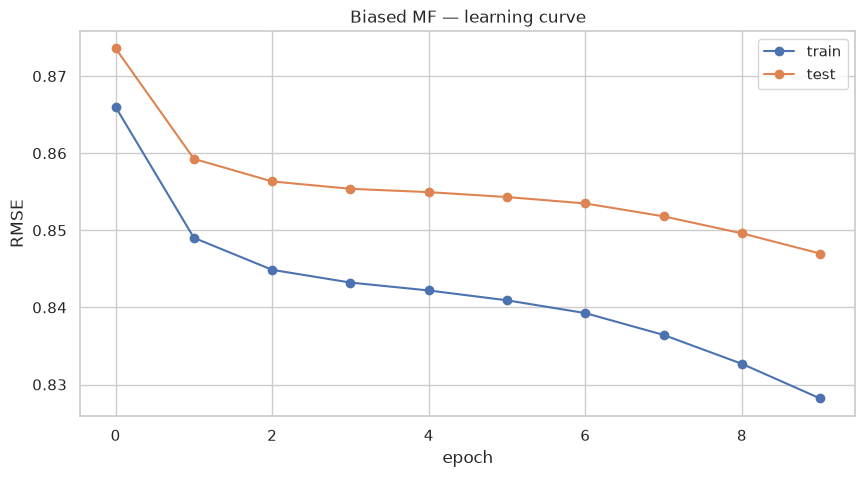

In [15]:
history = pd.DataFrame(mf.history_)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.epoch, history.train_rmse, marker="o", label="train")
ax.plot(history.epoch, history.val_rmse, marker="o", label="test")
ax.set(xlabel="epoch", ylabel="RMSE", title="Biased MF — learning curve")
ax.legend()
plt.show()

In [16]:
global_mean = np.full_like(y_test, y_train.mean())
rating_results = pd.DataFrame(
    [
        {"model": "Global mean", "RMSE": br.rmse(y_test, global_mean), "MAE": br.mae(y_test, global_mean)},
        {"model": "Damped item mean (popularity)",
         "RMSE": br.rmse(y_test, popularity_model.predict(None, test.book_id.to_numpy())),
         "MAE": br.mae(y_test, popularity_model.predict(None, test.book_id.to_numpy()))},
        {"model": "Biased MF (32 factors)",
         "RMSE": br.rmse(y_test, mf.predict(u_test, i_test)),
         "MAE": br.mae(y_test, mf.predict(u_test, i_test))},
    ]
).set_index("model")
display(rating_results.round(4))

,RMSE,MAE
model,,
Global mean,0.9911,0.7742
Damped item mean (popularity),0.9539,0.7626
Biased MF (32 factors),0.8470,0.6617


**Result.** The factorisation brings the RMSE from **0.99** (global mean) to **0.85**, i.e.
~14 % better, and the MAE from 0.77 to 0.66. The gap between train and test RMSE stays small,
so with `reg = 0.05` the model is not overfitting yet.

**Adding factors or epochs buys very little past this point** (see the ablation in Part 6) — the remaining error is the intrinsic
noise of the "how many stars?" question.

---

## 5. Recommending: the top-10 problem

A recommender does not show a predicted rating to the reader, it shows **a list**. So let us
rank the whole catalogue with the model we just trained and look at what comes out.

In [17]:
mf_ranking = br.evaluate_ranking(
    mf, seen_items, relevant_items, k=K, users=eval_users, n_items=index.n_items
)
popularity_ranking = br.evaluate_ranking(
    popularity_model.ranker(index.items, by="count"), seen_items, relevant_items,
    k=K, users=eval_users, n_items=index.n_items,
)
best_rated_ranking = br.evaluate_ranking(
    popularity_model.ranker(index.items, by="score"), seen_items, relevant_items,
    k=K, users=eval_users, n_items=index.n_items,
)

display(pd.DataFrame(
    [popularity_ranking, best_rated_ranking, mf_ranking],
    index=["MostPopular (by count)", "BestRated (damped mean)", "Biased MF (RMSE winner)"],
).round(4))

,precision@10,recall@10,ndcg@10,coverage,n_users
MostPopular (by count),0.0796,0.0538,0.0903,0.0034,2000
BestRated (damped mean),0.0020,0.0013,0.0021,0.0020,2000
Biased MF (RMSE winner),0.0023,0.0017,0.0024,0.1138,2000


**This is the most important result of the TP.** The model with the best RMSE produces the
*worst* top-10 lists — some thirty times less precise than simply showing everybody the
most-rated books. Let us look at what it actually recommends.

In [18]:
train_counts = train.groupby("book_id").size().reindex(index.items).fillna(0).to_numpy()

user = eval_users[0]
scores = mf.score_all_items(user)
scores[seen_items[user]] = -np.inf
top = np.argsort(-scores)[:10]

display(
    titles.loc[index.items[top], ["title", "authors"]]
    .assign(predicted_rating=np.round(scores[top], 2),
            n_ratings_in_train=train_counts[top].astype(int))
)

,title,authors,predicted_rating,n_ratings_in_train
book_id,,,,
8946,The Divan,Hafez,4.99,60
3628,The Complete Calvin and Hobbes,Bill Watterson,4.95,381
9566,Attack of the Deranged Mutant Killer Monster Snow Goons,Bill Watterson,4.87,129
6920,The Indispensable Calvin and Hobbes,Bill Watterson,4.83,173
5207,The Days Are Just Packed: A Calvin and Hobbes Collection,Bill Watterson,4.82,216
4868,Jesus the Christ,James E. Talmage,4.81,178
7947,ESV Study Bible,"Anonymous, Lane T. Dennis, Wayne A. Grudem",4.81,72
862,"Words of Radiance (The Stormlight Archive, #2)",Brandon Sanderson,4.80,1128
5580,The Calvin and Hobbes Lazy Sunday Book,Bill Watterson,4.79,217


**Diagnosis.** The list is full of niche books rated by a few hundred enthusiasts —
Calvin & Hobbes collections, study bibles, volume 2 of an epic fantasy series. Their item bias
$b_i$ is huge *because* only the fans who already follow the series ever rate them, and the
squared error has no reason to fight that: predicting 4.9 for a book almost nobody will open
costs nothing on the test set, since we are only scored on the pairs we observe. The model is
excellent at "how many stars, **given that** the reader opens this book" and was never asked
"will this reader open this book at all?".

This is the classic **RMSE ≠ ranking** gap. Three ways out:

1. rank by a *relevance* signal instead of a predicted rating (what we do next),
2. train a model whose loss *is* a ranking loss (BPR, WARP — out of scope here),
3. post-filter the predictions by popularity (crude, but it does help — measured in Part 6.3).

### 5.1 Item-based collaborative filtering on implicit feedback

Instead of "how many stars will this reader give?", we ask "which books are liked by the same
people?". Each book becomes the **binary column** of the readers who rated it ≥ 4, two books
are similar when their columns point in the same direction (cosine), and only the `k` nearest
neighbours of each book are kept — the remaining similarities come from a handful of shared
readers and are mostly noise.

The score of a candidate book is the sum of its similarities to the books the reader liked,
i.e. a single sparse product `user_row @ similarity_matrix`.

In [19]:
item_knn_100 = br.ItemKNNRecommender(k=100, like_threshold=4.0).fit(
    u_train, i_train, y_train, index.n_users, index.n_items
)
print(f"similarity matrix: {item_knn_100.similarity_.shape} with "
      f"{item_knn_100.similarity_.nnz:,} stored similarities "
      f"({100 * item_knn_100.similarity_.nnz / index.n_items ** 2:.2f}% of the full matrix)")

neighbours, similarity = item_knn_100.similar_items(index.item_pos[2], n=5)
print("\nBooks liked by the same readers as 'Harry Potter and the Sorcerer's Stone':")
display(titles.loc[index.items[neighbours], ["title", "authors"]].assign(cosine=np.round(similarity, 3)))

similarity matrix: (10000, 10000) with 1,000,000 stored similarities (1.00% of the full matrix)

Books liked by the same readers as 'Harry Potter and the Sorcerer's Stone':


,title,authors,cosine
book_id,,,
18,"Harry Potter and the Prisoner of Azkaban (Harry Potter, #3)","J.K. Rowling, Mary GrandPré, Rufus Beck",0.517
23,"Harry Potter and the Chamber of Secrets (Harry Potter, #2)","J.K. Rowling, Mary GrandPré",0.511
24,"Harry Potter and the Goblet of Fire (Harry Potter, #4)","J.K. Rowling, Mary GrandPré",0.509
25,"Harry Potter and the Deathly Hallows (Harry Potter, #7)","J.K. Rowling, Mary GrandPré",0.492
21,"Harry Potter and the Order of the Phoenix (Harry Potter,...","J.K. Rowling, Mary GrandPré",0.491


Compare this list with the content-based neighbours of the same book in Part 2.4: TF-IDF
returns the *other Harry Potter volumes* (same words, same author), while collaborative
filtering returns what Harry Potter readers *also* liked. The two signals are complementary —
which is the whole argument for a hybrid.

**How many neighbours?** `k` is the only real hyper-parameter of the model, so we measure it
instead of guessing. The sweep below (and every other tuning experiment in this notebook) is
run on 500 readers to stay fast; the final comparison uses the full sample of 2 000.

In [20]:
tuning_users = eval_users[:500]

def ranking_score(model, users=tuning_users):
    """NDCG@K and coverage of a model, on a small sample of readers."""
    return br.evaluate_ranking(
        model, seen_items, relevant_items, k=K, users=users, n_items=index.n_items
    )


neighbourhood_rows = []
knn_models = {}
for k_neighbours in [3, 5, 10, 20, 50, 100, 200]:
    knn_models[k_neighbours] = br.ItemKNNRecommender(k=k_neighbours).fit(
        u_train, i_train, y_train, index.n_users, index.n_items
    )
    scores = ranking_score(knn_models[k_neighbours])
    neighbourhood_rows.append({"k neighbours": k_neighbours,
                               f"NDCG@{K}": scores[f"ndcg@{K}"],
                               "coverage": scores["coverage"]})

neighbourhood = pd.DataFrame(neighbourhood_rows).set_index("k neighbours")
display(neighbourhood.round(4))

,NDCG@10,coverage
k neighbours,,
3,0.3620,0.1761
5,0.3592,0.1661
10,0.3353,0.1486
20,0.3137,0.1266
50,0.2868,0.1066
100,0.2821,0.0949
200,0.2772,0.0876


**Fewer, sharper neighbours win.** The quality peaks at 3-5 neighbours — the gap between the
two is within the noise of a 500-reader sample — and decays
slowly afterwards; coverage decays with it, so there is no trade-off to arbitrate — a large
neighbourhood is simply worse on both counts. The reason is the density of this dataset: with
~600 ratings per book on average, the 5 closest books are already supported by hundreds of
common readers, and neighbours 50 to 200 mostly add bestsellers that are close to *everything*.

We keep `k = 5` for the rest of the notebook.

In [21]:
item_knn = knn_models[5]

### 5.2 Hybrid: collaborative first, content as a tie-breaker

The two scores are not comparable (a sum of cosines vs a cosine), so each is min-max
normalised per reader before the blend

$$s(u, i) = \alpha \, \tilde s_{\text{kNN}}(u, i) + (1 - \alpha) \, \tilde s_{\text{content}}(u, i).$$

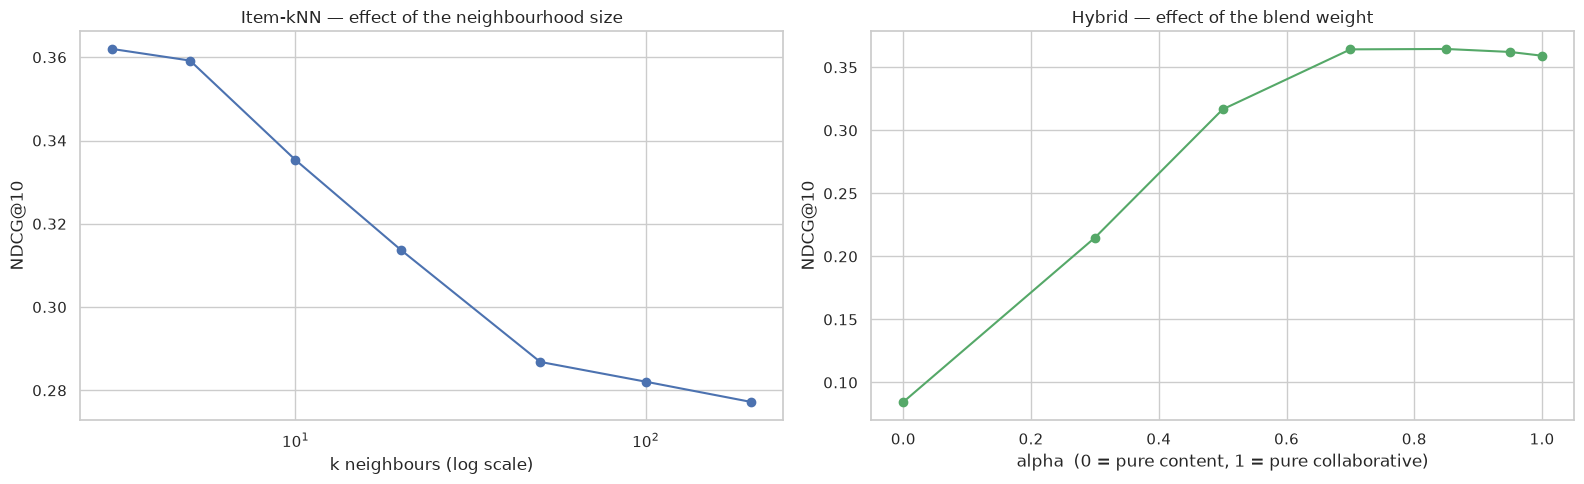

,NDCG@10,coverage
alpha,,
0.00,0.0845,0.1203
0.30,0.2149,0.1608
0.50,0.3167,0.1874
0.70,0.3642,0.1881
0.85,0.3645,0.1755
0.95,0.3622,0.1683
1.00,0.3592,0.1661


In [22]:
alpha_rows = []
for alpha in [0.0, 0.3, 0.5, 0.7, 0.85, 0.95, 1.0]:
    scores = ranking_score(br.HybridRecommender(item_knn, content_model, alpha=alpha))
    alpha_rows.append({"alpha": alpha, f"NDCG@{K}": scores[f"ndcg@{K}"],
                       "coverage": scores["coverage"]})

alpha_sweep = pd.DataFrame(alpha_rows).set_index("alpha")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
neighbourhood[f"NDCG@{K}"].plot(marker="o", ax=axes[0], logx=True)
axes[0].set(title="Item-kNN — effect of the neighbourhood size",
            ylabel=f"NDCG@{K}", xlabel="k neighbours (log scale)")
alpha_sweep[f"NDCG@{K}"].plot(marker="o", color=sns.color_palette()[2], ax=axes[1])
axes[1].set(title="Hybrid — effect of the blend weight", ylabel=f"NDCG@{K}",
            xlabel="alpha  (0 = pure content, 1 = pure collaborative)")
plt.tight_layout()
plt.show()
display(alpha_sweep.round(4))

The blend curve has an interior optimum, flat between `alpha = 0.7` and `alpha = 0.85`: most
of the signal is collaborative, but the last 15 % of content is worth ~1.5 % of NDCG *and* a
better coverage —
the content score breaks the ties between the many books that share a similar collaborative
score. We keep `alpha = 0.85`.

In [23]:
hybrid = br.HybridRecommender(item_knn, content_model, alpha=0.85)

ranking_results = pd.DataFrame(
    [
        popularity_ranking,
        best_rated_ranking,
        mf_ranking,
        br.evaluate_ranking(content_model, seen_items, relevant_items, k=K,
                            users=eval_users, n_items=index.n_items),
        br.evaluate_ranking(item_knn, seen_items, relevant_items, k=K,
                            users=eval_users, n_items=index.n_items),
        br.evaluate_ranking(hybrid, seen_items, relevant_items, k=K,
                            users=eval_users, n_items=index.n_items),
    ],
    index=["MostPopular (by count)", "BestRated (damped mean)", "Biased MF",
           "Content-based TF-IDF", "Item-kNN (k=5, implicit)",
           "Hybrid (0.85 kNN + 0.15 content)"],
).drop(columns="n_users")
display(ranking_results.round(4))

,precision@10,recall@10,ndcg@10,coverage
MostPopular (by count),0.0796,0.0538,0.0903,0.0034
BestRated (damped mean),0.0020,0.0013,0.0021,0.0020
Biased MF,0.0023,0.0017,0.0024,0.1138
Content-based TF-IDF,0.0767,0.0534,0.0858,0.2256
"Item-kNN (k=5, implicit)",0.3074,0.2060,0.3569,0.3138
Hybrid (0.85 kNN + 0.15 content),0.3132,0.2096,0.3626,0.3359


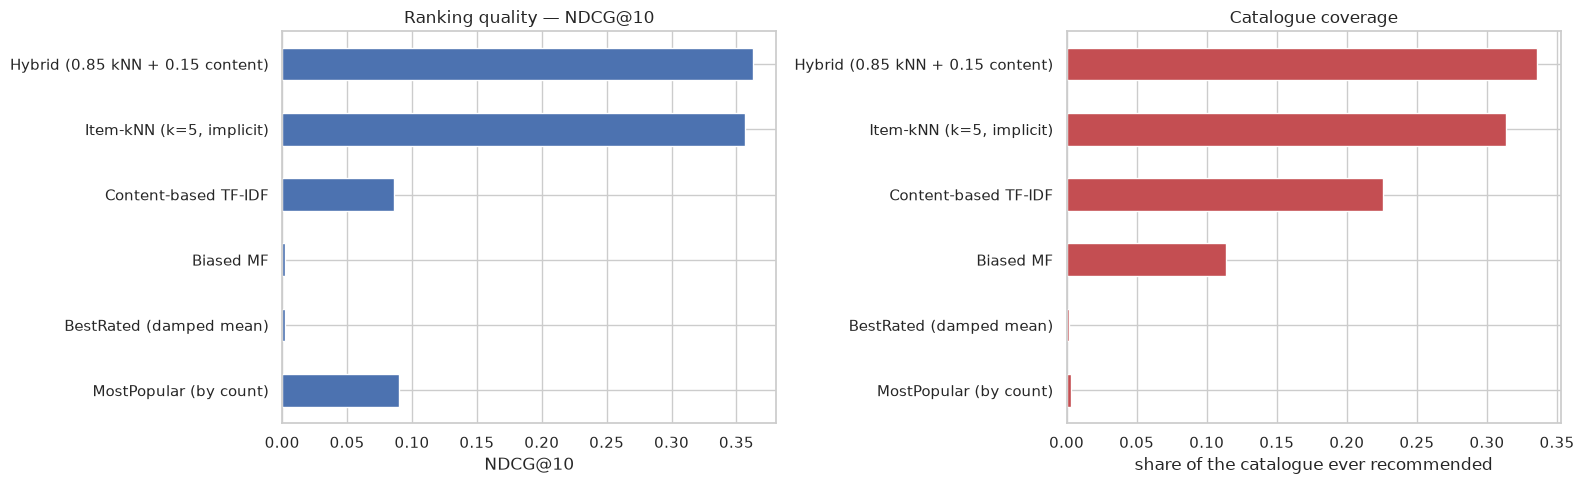

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ranking_results[f"ndcg@{K}"].plot.barh(ax=axes[0], color=sns.color_palette()[0])
axes[0].set(title=f"Ranking quality — NDCG@{K}", xlabel=f"NDCG@{K}")
ranking_results["coverage"].plot.barh(ax=axes[1], color=sns.color_palette()[3])
axes[1].set(title="Catalogue coverage", xlabel="share of the catalogue ever recommended")
plt.tight_layout()
plt.show()

**Results and reading.**

* **Item-kNN is four times more precise than the MostPopular baseline** on every ranking
  metric — personalisation pays, as soon as the model is asked the right question.
* The **hybrid** adds a further half-point of NDCG on top of item-kNN (0.357 → 0.363) and
  recommends a wider catalogue (0.31 → 0.34).
* **Content-based alone is on a par with MostPopular** in precision, but look at the coverage
  (0.23 vs 0.003): it recommends a genuinely varied catalogue, and Part 7 shows it is the only
  model that can recommend a book nobody has rated yet.
* The **coverage of MostPopular is 0.3 %** — 34 books shown to 2 000 readers. A recommender
  that only repeats bestsellers has little reason to exist.

---

## 6. What actually drives the performance?

> *"Discuss how different features and the size of the dataset affect the model's performance."*

The neighbourhood size and the blend weight were tuned in Part 5. Three questions are left:
how much data do we need, which content features earn their place, and can the factorisation
be rescued as a ranker? As before, the ranking metrics here are averaged over 500 readers
(±0.01 on NDCG).

### 6.1 How much data do we actually need?

In [25]:
size_rows = []
for fraction in [0.1, 0.25, 0.5, 1.0]:
    subset = train.sample(frac=fraction, random_state=SEED)
    sub_u = index.encode_users(subset.user_id)
    sub_i = index.encode_items(subset.book_id)
    sub_y = subset.rating.to_numpy(float)

    sub_mf = br.BiasedMF(n_factors=32, n_epochs=5, seed=SEED, verbose=False).fit(
        sub_u, sub_i, sub_y, index.n_users, index.n_items
    )
    sub_knn = br.ItemKNNRecommender(k=5).fit(
        sub_u, sub_i, sub_y, index.n_users, index.n_items
    )
    size_rows.append({
        "fraction of the train set": fraction,
        "ratings used": len(subset),
        "MF RMSE": br.rmse(y_test, sub_mf.predict(u_test, i_test)),
        f"item-kNN NDCG@{K}": ranking_score(sub_knn)[f"ndcg@{K}"],
    })

size_effect = pd.DataFrame(size_rows).set_index("fraction of the train set")
display(size_effect.round(4))

,ratings used,MF RMSE,item-kNN NDCG@10
fraction of the train set,,,
0.10,480257,0.9079,0.0330
0.25,1200642,0.8757,0.2115
0.50,2401284,0.8612,0.2954
1.00,4802569,0.8547,0.3592


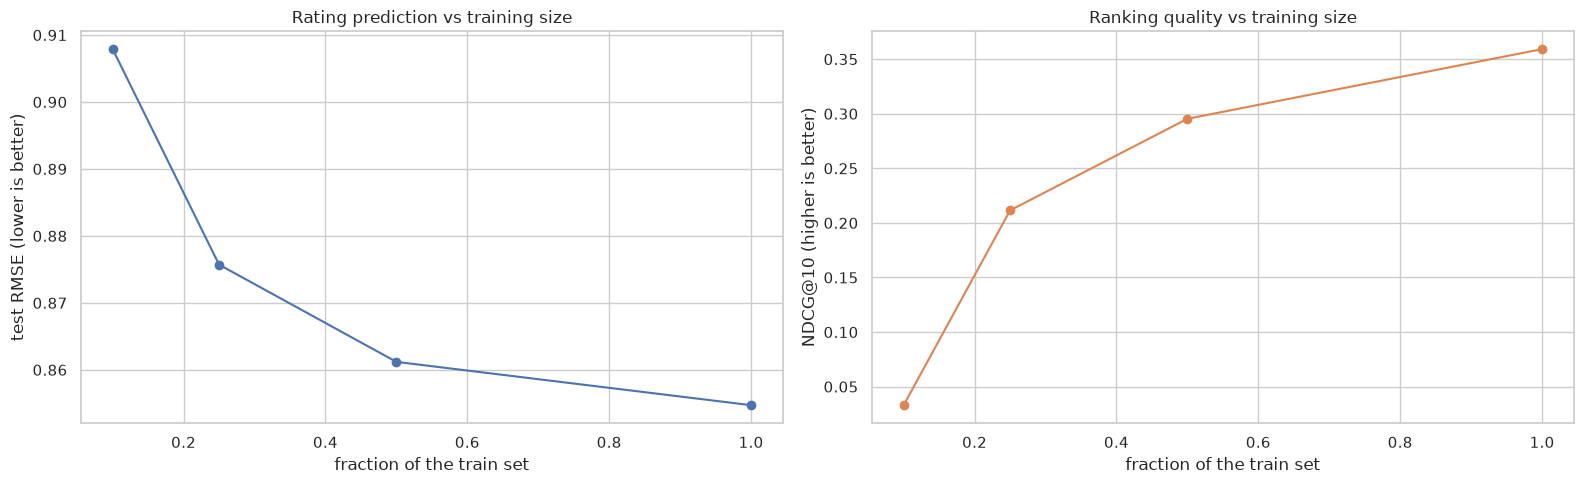

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
size_effect["MF RMSE"].plot(marker="o", ax=axes[0])
axes[0].set(title="Rating prediction vs training size", ylabel="test RMSE (lower is better)")
size_effect[f"item-kNN NDCG@{K}"].plot(marker="o", color=sns.color_palette()[1], ax=axes[1])
axes[1].set(title="Ranking quality vs training size", ylabel=f"NDCG@{K} (higher is better)")
plt.tight_layout()
plt.show()

**The two curves do not have the same shape, and that is the interesting part.**

The RMSE degrades gently — with a tenth of the ratings the factorisation is still within 6 %
of its final score, because biases are estimated from many observations and are most of what
the RMSE rewards.

The ranking quality **collapses** on the same subset (NDCG divided by ten). Item-kNN does not
count ratings, it counts *co-occurrences*: with 10 % of the ratings, two books share ten times
fewer common readers and the similarities become noise. It has recovered 80 % of its quality by
the half of the data, and is still improving at the end.

Practical consequence: the amount of data a recommender needs depends on the question asked of
it. Rating prediction degrades gracefully, neighbourhood models fall off a cliff — and a young
product, with few interactions, is precisely in the regime where content-based features are
the only reliable signal.

### 6.2 Which content features matter?

In [27]:
feature_rows = []
for name, kwargs in [
    ("title only", dict(use_authors=False, use_tags=False)),
    ("+ authors", dict(use_authors=True, use_tags=False)),
    ("+ authors + tags", dict(use_authors=True, use_tags=True)),
    ("+ authors + tags (shelving tags kept)",
     dict(use_authors=True, use_tags=True, drop_shelf_tags=False)),
]:
    variant_corpus = br.build_content_corpus(books, book_tags, tags, n_tags=12, **kwargs)
    variant = br.ContentBasedRecommender(min_df=3).fit(variant_corpus, index.items)
    variant.build_user_profiles(u_train, i_train, y_train, index.n_users)
    alone = ranking_score(variant)
    blended = ranking_score(br.HybridRecommender(item_knn, variant, alpha=0.85))
    feature_rows.append({
        "content features": name,
        "vocabulary": variant.X_.shape[1],
        f"NDCG@{K} alone": alone[f"ndcg@{K}"],
        "coverage alone": alone["coverage"],
        f"NDCG@{K} in the hybrid": blended[f"ndcg@{K}"],
    })

display(pd.DataFrame(feature_rows).set_index("content features").round(4))

,vocabulary,NDCG@10 alone,coverage alone,NDCG@10 in the hybrid
content features,,,,
title only,2592,0.1070,0.1901,0.3615
+ authors,3711,0.1415,0.1940,0.3635
+ authors + tags,5042,0.0845,0.1203,0.3645
+ authors + tags (shelving tags kept),4591,0.0696,0.0951,0.3618


**A result worth reading twice.** Used *alone*, the best content model is the simplest one:
`title + authors`. Adding the tags costs it 40 % of its NDCG — and yet the ordering reverses
inside the hybrid, where the tagged version is (marginally) the one that helps most.

The explanation is what the two roles ask of the representation. Alone, the content model
must *rank*: author tokens are sharp and discriminative ("same author" is most of what
"similar book" means to a reader), whereas the tags of a bestseller are `fiction`,
`young-adult`, `romance` — shared by hundreds of books, so they flatten the ranking towards
whatever is generic. Inside the hybrid, the collaborative score already decides *who* is
relevant, and the content score only has to break ties: there, a genre signal separates
candidates that the author token cannot distinguish at all.

The spread inside the hybrid is small (0.3615 to 0.3645), which is itself informative: once a
good collaborative model is in place, the content features are a second-order effect — except
for the cold-start case of Part 7.2, where they are the only thing left.

Keeping the shelving tags (`to-read`, `owned`, …) hurts in both roles, as expected: they
describe the reader's shelf, not the book.

### 6.3 Can we rescue the matrix factorisation as a ranker?

In [28]:
class PopularityFilteredMF:
    """MF predictions, restricted to books with enough ratings in the train set."""

    def __init__(self, model, counts, min_ratings):
        self.model, self.mask = model, counts >= min_ratings

    def score_all_items(self, user):
        scores = self.model.score_all_items(user).copy()
        scores[~self.mask] = -np.inf
        return scores


rescue = pd.DataFrame(
    [ranking_score(mf)] +
    [ranking_score(PopularityFilteredMF(mf, train_counts, m)) for m in (200, 1000, 5000)],
    index=["no filter", "books with >= 200 ratings", ">= 1 000 ratings", ">= 5 000 ratings"],
).drop(columns="n_users")
display(rescue.round(4))

,precision@10,recall@10,ndcg@10,coverage
no filter,0.0018,0.0015,0.0024,0.0539
books with >= 200 ratings,0.0028,0.0017,0.0026,0.0412
>= 1 000 ratings,0.0142,0.0095,0.0131,0.0198
>= 5 000 ratings,0.0482,0.0324,0.0530,0.0051


Filtering by popularity multiplies the precision of the factorisation by more than an order of
magnitude — and still leaves it six times behind item-kNN, while destroying the coverage
(the filter throws away most of the catalogue). A rating-prediction model is not a ranking
model; patching it afterwards is a workaround, not a fix.

---

## 7. Cold start

Everything above assumes ~90 ratings per reader and hundreds of ratings per book. Two
questions remain, and they have opposite answers.

### 7.1 A new reader

We simulate a reader who has just told us about `n` books, by keeping only the first `n`
books of their history as the entire profile.

model,Content-based TF-IDF,Hybrid (alpha=0.85),Item-kNN
profile size,,,
1,0.0295,0.0470,0.0410
3,0.0475,0.0750,0.0742
5,0.0490,0.0810,0.0823
10,0.0469,0.1013,0.1007


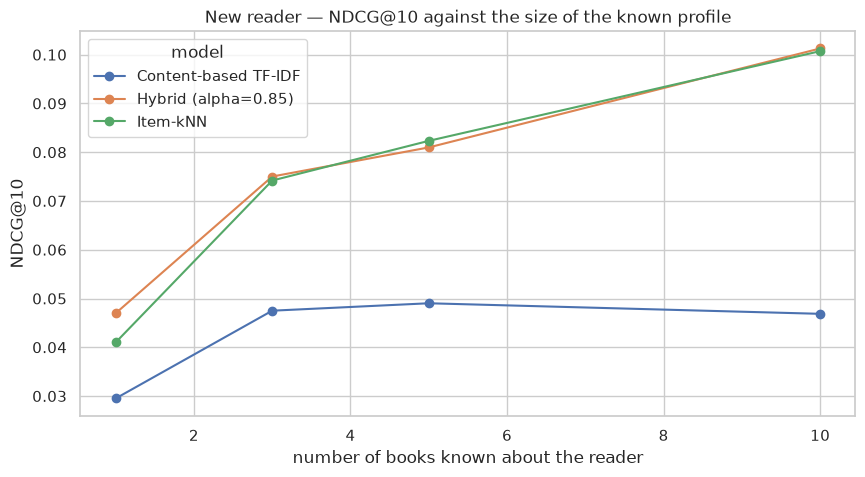

In [29]:
cold_rows = []
cold_candidates = [user for user in tuning_users if len(seen_items[user]) >= 10]

for profile_size in [1, 3, 5, 10]:
    profiles = {user: seen_items[user][:profile_size] for user in cold_candidates}
    for name, model in [
        ("Content-based TF-IDF", content_model),
        ("Item-kNN", item_knn),
        ("Hybrid (alpha=0.85)", hybrid),
    ]:
        scores = br.evaluate_cold_start(model, profiles, relevant_items, k=K,
                                        n_items=index.n_items)
        cold_rows.append({"profile size": profile_size, "model": name,
                          f"NDCG@{K}": scores[f"ndcg@{K}"]})

cold_start = pd.DataFrame(cold_rows).pivot(
    index="profile size", columns="model", values=f"NDCG@{K}"
)
display(cold_start.round(4))

cold_start.plot(marker="o", figsize=(10, 5),
                title=f"New reader — NDCG@{K} against the size of the known profile")
plt.xlabel("number of books known about the reader")
plt.ylabel(f"NDCG@{K}")
plt.show()

**The collaborative model wins even with a single book** (the hybrid is best of all on the
shortest profiles) — a result that contradicts the
textbook intuition, and the dataset explains why: every book of GoodBooks-10k already has at
least 8 ratings (and 250 on average), so "the readers who liked this book also liked…" is
available from the very first interaction. The content model is *behind* at every profile
size here.

The honest conclusion is therefore not "content-based solves the cold start", but: **the cold
start of a new *reader* is not a problem on a dense, well-covered catalogue**. What remains
expensive is the other side.

### 7.2 A new book

We hide 500 books from the collaborative model — as if they had just been added to the
catalogue — and ask each model to rank *those* 500 books for readers who, in the test set,
liked one of them.

In [30]:
new_books = rng.choice(index.items, size=500, replace=False)
new_positions = index.encode_items(new_books)
is_new = np.zeros(index.n_items, dtype=bool)
is_new[new_positions] = True

# Retrain both models without a single interaction on the new books.
keep = ~np.isin(i_train, new_positions)
knn_without_new = br.ItemKNNRecommender(k=5).fit(
    u_train[keep], i_train[keep], y_train[keep], index.n_users, index.n_items
)
content_without_new = br.ContentBasedRecommender(min_df=3).fit(corpus, index.items)
content_without_new.build_user_profiles(
    u_train[keep], i_train[keep], y_train[keep], index.n_users
)

seen_without_new = br.group_items_by_user(u_train[keep], i_train[keep], index.n_users)
relevant_new = {
    user: items[is_new[items]] for user, items in relevant_items.items()
    if is_new[items].any()
}
new_book_users = [user for user in tuning_users if user in relevant_new]


class RestrictedToNewBooks:
    """Ranks only the books the collaborative model has never seen."""

    def __init__(self, model):
        self.model = model

    def score_all_items(self, user):
        scores = np.array(self.model.score_all_items(user), dtype=float, copy=True)
        scores[~is_new] = -np.inf
        return scores


cold_item_results = pd.DataFrame(
    [
        br.evaluate_ranking(RestrictedToNewBooks(model), seen_without_new, relevant_new,
                            k=K, users=new_book_users, n_items=len(new_books))
        for model in (knn_without_new, content_without_new,
                      br.HybridRecommender(knn_without_new, content_without_new, alpha=0.85))
    ],
    index=["Item-kNN", "Content-based TF-IDF", "Hybrid"],
)
print(f"{len(new_book_users)} readers liked at least one of the 500 'new' books")
display(cold_item_results.round(4))

267 readers liked at least one of the 500 'new' books


,precision@10,recall@10,ndcg@10,coverage,n_users
Item-kNN,0.0034,0.0256,0.0101,0.020,267
Content-based TF-IDF,0.0427,0.2899,0.1743,0.614,267
Hybrid,0.0427,0.2899,0.1743,0.614,267


**Here the content model is not an improvement, it is the only option.** Item-kNN has no
similarity column for a book nobody has rated, so it scores every new book at zero and orders
them arbitrarily; TF-IDF vectors exist for all of them and recover ~29 % of the relevant new
books in a top-10 drawn from 500 candidates. The hybrid inherits the content behaviour exactly,
since the collaborative half is constant — which is the practical reason to keep a content
model in the blend even when, as in Part 5, it contributes little to the headline metric.

---

## 8. Recommending for a given reader

The function asked for by the exercise. It takes a reader, masks what they already read, and
returns a readable list.

In [31]:
def show_reader(user, n_history=5, n_recommendations=K):
    """Print the favourite books of a reader, then the recommendations of each model."""
    reader_ratings = train[train.user_id == index.users[user]]
    history = (
        reader_ratings.sort_values("rating", ascending=False)
        .head(n_history)
        .merge(books[["book_id", "title", "authors"]], on="book_id")
    )
    print(f"=== reader {index.users[user]} — {len(seen_items[user])} books read, "
          f"mean rating {reader_ratings.rating.mean():.2f}")
    display(history[["title", "authors", "rating"]])

    for name, model in [("Item-kNN", item_knn), ("Hybrid", hybrid),
                        ("Content-based", content_model)]:
        print(f"--- top {n_recommendations} — {name}")
        display(
            br.top_n_recommendations(model, user, index, titles, seen_items,
                                     n=n_recommendations)
            [["rank", "title", "authors", "score"]]
            .set_index("rank").round(3)
        )


show_reader(eval_users[1])

=== reader 14416 — 70 books read, mean rating 3.67


,title,authors,rating
0,The Help,Kathryn Stockett,5
1,The Secret Life of Bees,Sue Monk Kidd,5
2,Gone with the Wind,Margaret Mitchell,5
3,Pride and Prejudice,Jane Austen,5
4,Three Cups of Tea: One Man's Mission to Promote Peace .....,"Greg Mortenson, David Oliver Relin",5


--- top 10 — Item-kNN


,title,authors,score
rank,,,
1,"Four to Score (Stephanie Plum, #4)",Janet Evanovich,3.204
2,Jane Eyre,"Charlotte Brontë, Michael Mason",1.313
3,"Origin in Death (In Death, #21)",J.D. Robb,1.197
4,"Creation in Death (In Death, #25)",J.D. Robb,1.187
5,"Rapture in Death (In Death, #4)","J.D. Robb, Susan Ericksen",1.019
6,"Immortal in Death (In Death, #3)",J.D. Robb,0.993
7,"Vengeance in Death (In Death, #6)",J.D. Robb,0.967
8,"Ceremony in Death (In Death, #5)",J.D. Robb,0.932
9,Emma,"Jane Austen, Fiona Stafford",0.773


--- top 10 — Hybrid


,title,authors,score
rank,,,
1,"Four to Score (Stephanie Plum, #4)",Janet Evanovich,0.962
2,Jane Eyre,"Charlotte Brontë, Michael Mason",0.402
3,"Origin in Death (In Death, #21)",J.D. Robb,0.392
4,"Creation in Death (In Death, #25)",J.D. Robb,0.389
5,"Rapture in Death (In Death, #4)","J.D. Robb, Susan Ericksen",0.345
6,"Immortal in Death (In Death, #3)",J.D. Robb,0.343
7,"Ceremony in Death (In Death, #5)",J.D. Robb,0.339
8,"Vengeance in Death (In Death, #6)",J.D. Robb,0.334
9,Emma,"Jane Austen, Fiona Stafford",0.287


--- top 10 — Content-based


,title,authors,score
rank,,,
1,The Gargoyle,Andrew Davidson,0.405
2,"Smokin' Seventeen (Stephanie Plum, #17)","Janet Evanovich, Lorelei King",0.398
3,Big Girl Panties,Stephanie Evanovich,0.387
4,"Explosive Eighteen (Stephanie Plum, #18)",Janet Evanovich,0.385
5,"Sizzling Sixteen (Stephanie Plum, #16)",Janet Evanovich,0.382
6,"Top Secret Twenty-One (Stephanie Plum, #21)",Janet Evanovich,0.378
7,"Takedown Twenty (Stephanie Plum, #20)",Janet Evanovich,0.378
8,Love Walked In,Marisa de los Santos,0.378
9,"Where'd You Go, Bernadette",Maria Semple,0.377


In [32]:
show_reader(eval_users[7])

=== reader 14755 — 100 books read, mean rating 3.51


,title,authors,rating
0,Into Thin Air: A Personal Account of the Mount Everest D...,Jon Krakauer,5
1,"Master of the Senate (The Years of Lyndon Johnson, #3)",Robert A. Caro,5
2,Pilgrim at Tinker Creek,Annie Dillard,5
3,Truman,David McCullough,5
4,Mornings on Horseback,David McCullough,5


--- top 10 — Item-kNN


,title,authors,score
rank,,,
1,To Kill a Mockingbird,Harper Lee,1.406
2,"Little Women (Little Women, #1)",Louisa May Alcott,0.937
3,The Secret Life of Bees,Sue Monk Kidd,0.902
4,Emma,"Jane Austen, Fiona Stafford",0.773
5,Hawaii,James A. Michener,0.763
6,Centennial,James A. Michener,0.685
7,Memoirs of a Geisha,Arthur Golden,0.583
8,John Adams,David McCullough,0.477
9,The Covenant,James A. Michener,0.464


--- top 10 — Hybrid


,title,authors,score
rank,,,
1,To Kill a Mockingbird,Harper Lee,0.811
2,"Little Women (Little Women, #1)",Louisa May Alcott,0.551
3,The Secret Life of Bees,Sue Monk Kidd,0.525
4,Emma,"Jane Austen, Fiona Stafford",0.462
5,Hawaii,James A. Michener,0.457
6,Centennial,James A. Michener,0.408
7,Memoirs of a Geisha,Arthur Golden,0.389
8,John Adams,David McCullough,0.366
9,Theodore Rex,Edmund Morris,0.328


--- top 10 — Content-based


,title,authors,score
rank,,,
1,Mein Kampf,Adolf Hitler,0.570
2,All But My Life: A Memoir,Gerda Weissmann Klein,0.539
3,Detroit: An American Autopsy,Charlie LeDuff,0.539
4,This Time Together: Laughter and Reflection,Carol Burnett,0.523
5,Bossypants,Tina Fey,0.521
6,Wildflower,Drew Barrymore,0.517
7,All Over But the Shoutin',Rick Bragg,0.512
8,Wishful Drinking,Carrie Fisher,0.511
9,Maude,Donna Mabry,0.510


The lists are coherent with the histories, and the models fail differently: item-kNN stays
inside the reader's community (what that crowd reads next), the content model stays inside the
reader's *genre and authors* — including books the crowd never mentions. The hybrid keeps the
first behaviour and borrows a little of the second.

Both also show the limit noted in the conclusion: nothing prevents them from recommending
volume 4 of a series to someone who has just read volume 1, because "already read the previous
volumes" is a business rule, not a statistical signal.

### "Because you liked …"

The same similarity matrices answer the item-to-item question, which is what most e-commerce
sites actually display.

In [33]:
def book_id_of(title_fragment):
    """First book whose title contains the fragment (case-insensitive)."""
    matches = books[books.title.str.contains(title_fragment, case=False, regex=False)]
    if matches.empty:
        raise KeyError(title_fragment)
    return int(matches.book_id.iloc[0])


def similar_books(book_id, n=5):
    """Compare the collaborative and the content neighbours of a book."""
    position = index.item_pos[book_id]
    print(f"=== {titles.title.loc[book_id]} — {titles.authors.loc[book_id]}")

    knn_neighbours, knn_scores = item_knn.similar_items(position, n=n)
    content_neighbours, content_scores = content_model.similar_items(position, n=n)
    display(pd.DataFrame({
        "liked by the same readers": titles.title.reindex(index.items[knn_neighbours]).values,
        "cosine (implicit)": np.round(knn_scores, 3),
        "similar content": titles.title.reindex(index.items[content_neighbours]).values,
        "cosine (TF-IDF)": np.round(content_scores, 3),
    }))


similar_books(book_id_of("The Fellowship of the Ring"))
similar_books(book_id_of("The Da Vinci Code"))
similar_books(book_id_of("Gone Girl"))

=== The Fellowship of the Ring (The Lord of the Rings, #1) — J.R.R. Tolkien


,liked by the same readers,cosine (implicit),similar content,cosine (TF-IDF)
0,The Hobbit,0.504,"The Lord of the Rings (The Lord of the Rings, #1-3)",0.732
1,"The Two Towers (The Lord of the Rings, #2)",0.435,J.R.R. Tolkien 4-Book Boxed Set: The Hobbit and The Lord...,0.636
2,"The Return of the King (The Lord of the Rings, #3)",0.427,"The Two Towers (The Lord of the Rings, #2)",0.618
3,"Harry Potter and the Sorcerer's Stone (Harry Potter, #1)",0.353,The Lord of the Rings: The Art of The Fellowship of the ...,0.609
4,"The Lion, the Witch, and the Wardrobe (Chronicles of Nar...",0.304,"The Return of the King (The Lord of the Rings, #3)",0.608


=== The Da Vinci Code (Robert Langdon, #2) — Dan Brown


,liked by the same readers,cosine (implicit),similar content,cosine (TF-IDF)
0,"Angels & Demons (Robert Langdon, #1)",0.378,"Angels and Demons / The Da Vinci Code (Robert Langdon, #...",0.878
1,"The Lost Symbol (Robert Langdon, #3)",0.284,"The Lost Symbol (Robert Langdon, #3)",0.614
2,"Harry Potter and the Deathly Hallows (Harry Potter, #7)",0.283,"Angels & Demons (Robert Langdon, #1)",0.577
3,"Harry Potter and the Half-Blood Prince (Harry Potter, #6)",0.283,Digital Fortress,0.536
4,"Harry Potter and the Goblet of Fire (Harry Potter, #4)",0.281,"Inferno (Robert Langdon, #4)",0.532


=== Gone Girl — Gillian Flynn


,liked by the same readers,cosine (implicit),similar content,cosine (TF-IDF)
0,The Girl on the Train,0.309,The Girl You Lost,0.491
1,Dark Places,0.307,The Girl Before,0.479
2,Sharp Objects,0.285,Where They Found Her,0.459
3,The Help,0.275,Sharp Objects,0.451
4,"The Hunger Games (The Hunger Games, #1)",0.266,"Gone (Gone, #1)",0.429


---

## 9. Conclusions

**What was built.** A popularity baseline, a biased matrix factorisation trained by mini-batch
SGD, an item-based collaborative filter on implicit feedback, a TF-IDF content-based model and
a weighted hybrid — all evaluated on the same per-reader split, with both error and ranking
metrics, and all tuned on a held-out sample rather than by guesswork.

**What the numbers say.**

| Task | Winner | Score | Baseline |
|---|---|---|---|
| Predict a rating | Biased MF (32 factors) | RMSE 0.85 / MAE 0.66 | 0.99 / 0.77 (global mean) |
| Recommend 10 books | Hybrid (0.85 item-kNN + 0.15 content) | NDCG@10 ≈ 0.36, Precision@10 ≈ 0.31 | 0.09 / 0.08 (MostPopular) |
| Recommend a *new* book | Content-based (the only one that can) | Recall@10 ≈ 0.29 | ≈ 0.03 (item-kNN) |

**The four lessons of this TP.**

1. **The metric defines the model.** The best RMSE model is the worst ranker: minimising the
   squared error on observed ratings rewards confident predictions on books nobody will read.
   Pick the metric that matches what the product shows, then pick the model.
2. **Personalisation must beat popularity, and be shown to.** MostPopular is a serious
   baseline; item-kNN is four times more precise *and* shows 90× more of the catalogue.
   Coverage is what separates a recommender from a bestseller list.
3. **Collaborative and content signals are complementary, not competing.** The content model
   loses every head-to-head on this dense catalogue, and is still irreplaceable: it is the only
   model that can rank a book with no ratings, and the tie-breaker that improves the hybrid.
4. **Data size affects the two families differently.** Halving the ratings costs 0.8 % of RMSE
   but 18 % of NDCG, and a tenth of the ratings makes the neighbourhood model collapse
   entirely: it needs co-occurrences, not observations.

**Limits of this work, and what would come next.**

* No timestamps, so the split is random rather than chronological: every number here is
  optimistic with respect to a real deployment, where the model only knows the past.
* Offline metrics only. Precision@10 against past ratings cannot see that a reader would have
  loved a book they never encountered — the missing-not-at-random problem. An A/B test is the
  only real answer.
* Obvious next models: a ranking loss (BPR, WARP) instead of the squared error, and embeddings
  learnt jointly from content and interactions (two-tower / NCF, Session 06).
* Obvious next features: series and publication year (to stop recommending volume 4 to a reader
  who has just read volume 1), and a diversity re-ranking step: a third of the catalogue ever
  recommended is better than 0.3 %, but two thirds of the books are still never shown.